<center> <b> <h1> Swiggy Delivery Time Prediction Project using Traditional Machine Learning </h1> </b> </center>

In [66]:
#Import required libraries:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [67]:
#Load the dataset:
df = pd.read_csv("dataset/swiggy.csv")
df.head()

,ID,Area,City,Restaurant,Price,Avg ratings,Total ratings,Food type,Address,Delivery time
0,211,Koramangala,Bangalore,Tandoor Hut,300.0,4.4,100,"Biryani,Chinese,North Indian,South Indian",5Th Block,59
1,221,Koramangala,Bangalore,Tunday Kababi,300.0,4.1,100,"Mughlai,Lucknowi",5Th Block,56
2,246,Jogupalya,Bangalore,Kim Lee,650.0,4.4,100,Chinese,Double Road,50
3,248,Indiranagar,Bangalore,New Punjabi Hotel,250.0,3.9,500,"North Indian,Punjabi,Tandoor,Chinese",80 Feet Road,57
4,249,Indiranagar,Bangalore,Nh8,350.0,4.0,50,"Rajasthani,Gujarati,North Indian,Snacks,Desser...",80 Feet Road,63


In [68]:
#Check for any null-values:
df.isnull().sum()

ID               0
Area             0
City             0
Restaurant       0
Price            0
Avg ratings      0
Total ratings    0
Food type        0
Address          0
Delivery time    0
dtype: int64

In [69]:
#Check for any duplicate values:
df.duplicated().sum()

np.int64(0)

In [70]:
df.describe()

,ID,Price,Avg ratings,Total ratings,Delivery time
count,8680.000000,8680.000000,8680.000000,8680.000000,8680.000000
mean,244812.071429,348.444470,3.655104,156.634793,53.967051
std,158671.617188,230.940074,0.647629,391.448014,14.292335
min,211.000000,0.000000,2.000000,20.000000,20.000000
25%,72664.000000,200.000000,2.900000,50.000000,44.000000
50%,283442.000000,300.000000,3.900000,80.000000,53.000000
75%,393425.250000,400.000000,4.200000,100.000000,64.000000
max,466928.000000,2500.000000,5.000000,10000.000000,109.000000


In [71]:
#View basic information about the dataset:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8680 entries, 0 to 8679
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             8680 non-null   int64  
 1   Area           8680 non-null   object 
 2   City           8680 non-null   object 
 3   Restaurant     8680 non-null   object 
 4   Price          8680 non-null   float64
 5   Avg ratings    8680 non-null   float64
 6   Total ratings  8680 non-null   int64  
 7   Food type      8680 non-null   object 
 8   Address        8680 non-null   object 
 9   Delivery time  8680 non-null   int64  
dtypes: float64(2), int64(3), object(5)
memory usage: 678.3+ KB


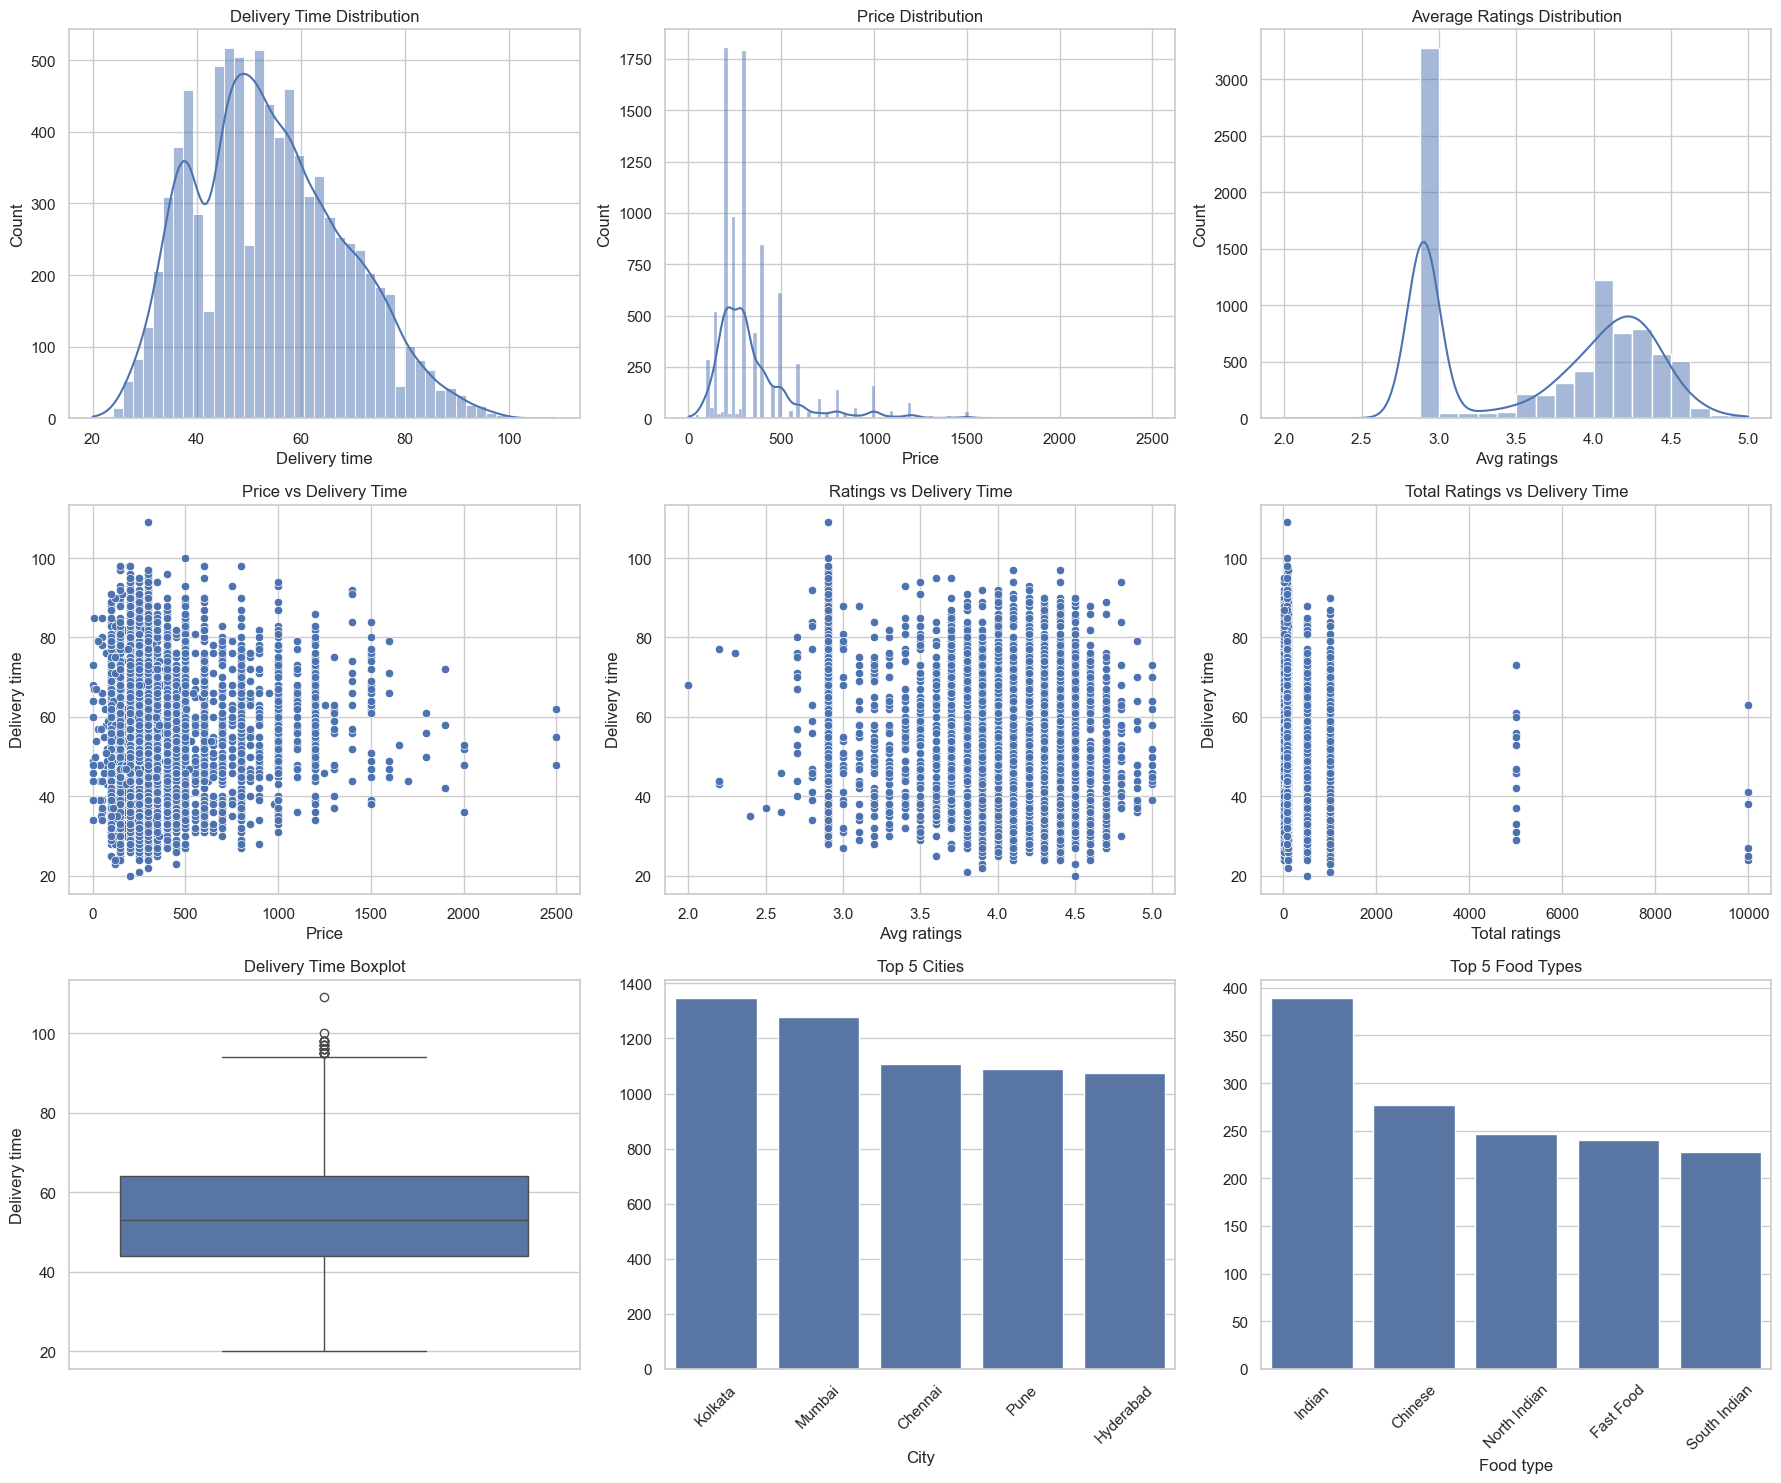

In [72]:
# Basic EDA:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np  # For numeric column selection

# Set style
sns.set(style="whitegrid")

# Create 3x3 subplot grid
fig, axes = plt.subplots(3, 3, figsize=(18, 15))

# ========== ROW 1 ==========
# 1. Delivery Time Distribution
sns.histplot(df['Delivery time'], kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Delivery Time Distribution")

# 2. Price Distribution
sns.histplot(df['Price'], kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Price Distribution")

# 3. Avg Ratings Distribution
sns.histplot(df['Avg ratings'], kde=True, ax=axes[0, 2])
axes[0, 2].set_title("Average Ratings Distribution")

# ========== ROW 2 ==========
# 4. Delivery Time vs Price
sns.scatterplot(x=df['Price'], y=df['Delivery time'], ax=axes[1, 0])
axes[1, 0].set_title("Price vs Delivery Time")

# 5. Delivery Time vs Avg Ratings
sns.scatterplot(x=df['Avg ratings'], y=df['Delivery time'], ax=axes[1, 1])
axes[1, 1].set_title("Ratings vs Delivery Time")

# 6. Total Ratings vs Delivery Time
sns.scatterplot(x=df['Total ratings'], y=df['Delivery time'], ax=axes[1, 2])
axes[1, 2].set_title("Total Ratings vs Delivery Time")

# ========== ROW 3 ==========
# 7. Boxplot of Delivery Time
sns.boxplot(y=df['Delivery time'], ax=axes[2, 0])
axes[2, 0].set_title("Delivery Time Boxplot")

# 8. Top 5 Cities Count
top_cities = df['City'].value_counts().head(5)
sns.barplot(x=top_cities.index, y=top_cities.values, ax=axes[2, 1])
axes[2, 1].set_title("Top 5 Cities")
axes[2, 1].tick_params(axis='x', rotation=45)

# 9. Top 5 Food Types Count
top_food_types = df['Food type'].value_counts().head(5)
sns.barplot(x=top_food_types.index, y=top_food_types.values, ax=axes[2, 2])
axes[2, 2].set_title("Top 5 Food Types")
axes[2, 2].tick_params(axis='x', rotation=45)


# Adjust layout
plt.tight_layout()
plt.show()

### Q1] Predict the Delivery time of an order using restaurant, pricing, ratings, and location features.

In [73]:
#Feature / Target Split:
X = df.drop(columns=['Delivery time', 'ID', 'Food type'])
y = df['Delivery time']

#Train-Test Split:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Preprocessing:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])


In [74]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import ExtraTreesRegressor, AdaBoostRegressor
from xgboost import XGBRegressor


#Linear Regression:
lr_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LinearRegression())
])


#KNN Regressor:
knn_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', KNeighborsRegressor())
])


#Decision-tree Regressor:
dt_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', DecisionTreeRegressor(random_state=42))
])


#Extra-trees Regressor:
et_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', ExtraTreesRegressor(n_estimators=250, max_depth=5, random_state=42))
])


#Adaboost:
ada_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', AdaBoostRegressor(
        estimator=DecisionTreeRegressor(max_depth=7),
        n_estimators=400,
        learning_rate=0.5,
        random_state=42
    ))
])


#XG-Boost:
xgb_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ))
])

In [75]:
#Model dictionary:
models = {
    "Linear Regression": lr_pipeline,
    "KNN": knn_pipeline,
    "Decision Tree": dt_pipeline,
    "Extra Trees": et_pipeline,
    "AdaBoost": ada_pipeline,
    "XGBoost":xgb_pipeline
}

In [76]:
#Cross validation:

from sklearn.model_selection import KFold, cross_validate

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'r2': 'r2',
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error'
}

results = []

for name, model in models.items():
    
    cv_results = cross_validate(
        model,
        X_train,
        y_train,
        cv=kf,
        scoring=scoring
    )
    
    mae = -np.mean(cv_results['test_mae'])
    rmse = -np.mean(cv_results['test_rmse'])
    r2 = np.mean(cv_results['test_r2'])
    
    results.append({
        "Model": name,
        "CV R2": round(r2, 4),
        "CV MAE": round(mae, 2),
        "CV RMSE": round(rmse, 2)
    })

results_df = pd.DataFrame(results).sort_values(by="CV R2", ascending=False)
print(results_df)

               Model   CV R2  CV MAE  CV RMSE
5            XGBoost  0.6644    6.33     8.25
1                KNN  0.6505    6.27     8.42
2      Decision Tree  0.5216    7.22     9.85
0  Linear Regression  0.4763    7.69    10.26
3        Extra Trees  0.3527    9.18    11.46
4           AdaBoost  0.3438    9.47    11.54


In [77]:
#Train the best model on Full-training data:
best_model = results_df.iloc[0]['Model']
print("Best Model:", best_model)

best_pipeline = models[best_model]
best_pipeline.fit(X_train, y_train)

Best Model: XGBoost


,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [78]:
#Test Evaluation on testing:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = best_pipeline.predict(X_test)

print("TEST RESULTS")
print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

TEST RESULTS
R2: 0.675024151802063
MAE: 6.412059307098389
RMSE: 8.241580250142036


In [79]:
#Now test on one single tuple:
single_data = pd.DataFrame({
    'Area': ['Vastrapur'],
    'City': ['Ahmedabad'],
    'Restaurant': ['Vanilla Sky'],
    'Price': [300.0],
    'Avg ratings': [2.9],
    'Address': ['Vastrapur'],
    'Total ratings': [220]
})

pred = best_pipeline.predict(single_data)
print("Predicted Delivery Time:", round(pred[0]), "minutes")

Predicted Delivery Time: 48 minutes


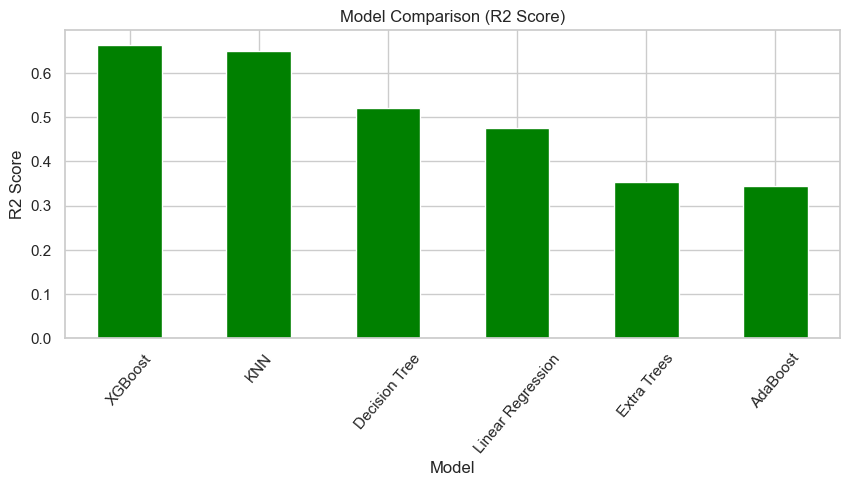

In [80]:
#Model comparison:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
results_df.set_index("Model")["CV R2"].plot(kind='bar',color="green")
plt.title("Model Comparison (R2 Score)")

plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.xticks(rotation=50)
plt.show()

In [81]:
#Export the best-performing model:
import joblib
joblib.dump(best_model,"Swiggy_FoodDeliveryTimePrediction_Model.pkl")

['Swiggy_FoodDeliveryTimePrediction_Model.pkl']

## CONCLUSION : We used several traditional-ml algorithms to predict the **delivery time**. The predicted **delivery time** is 48 minutes.

### Q2] Can we segment restaurants into different groups based on pricing and ratings to understand different business categories and optimize delivery strategies?

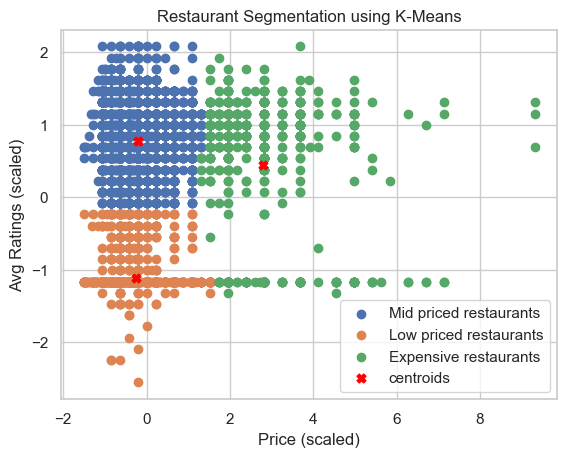

In [82]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# Step 1
X = df[['Price', 'Avg ratings']]

# Step 2
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 3
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Step 4
centroids = kmeans.cluster_centers_

# 🔥 Step 5: Map clusters based on PRICE (column index 0)
centroid_prices = centroids[:, 0]

sorted_idx = np.argsort(centroid_prices)

labels_map = {
    sorted_idx[0]: "Low priced restaurants",
    sorted_idx[1]: "Mid priced restaurants",
    sorted_idx[2]: "Expensive restaurants"
}

# Step 6: Plot
for i in range(3):
    plt.scatter(
        X_scaled[df['cluster'] == i, 0],
        X_scaled[df['cluster'] == i, 1],
        label=labels_map[i]
    )

# Plot centroids
plt.scatter(
    centroids[:, 0], centroids[:, 1],
    color='red', marker='X', s=40, label='centroids'
)

plt.xlabel('Price (scaled)')
plt.ylabel('Avg Ratings (scaled)')
plt.title('Restaurant Segmentation using K-Means')

plt.legend()
plt.show()

In [83]:
df['cluster_label'] = df['cluster'].map(labels_map)
df['cluster_label'].value_counts().reset_index(name="Frequency of this type of restaurant")

,cluster_label,Frequency of this type of restaurant
0,Mid priced restaurants,4573
1,Low priced restaurants,3456
2,Expensive restaurants,651


### Q3] Do high-priced restaurants have significantly higher average ratings than low-priced restaurants?

In [84]:
high_price = df[df['Price'] > df['Price'].median()]['Avg ratings']
low_price = df[df['Price'] <= df['Price'].median()]['Avg ratings']

import numpy as np
from statsmodels.stats.weightstats import ztest

z_stat, p_value = ztest(high_price, low_price, alternative='larger')

print("Z-statistic:", z_stat)
print("P-value:", p_value)


if(p_value<0.05):
    print("High-priced restaurants have higher ratings than low-priced ones")
else:
    print("High-priced restaurants do NOT have higher ratings than low-priced ones")

Z-statistic: 9.793477790926236
P-value: 6.004630306346148e-23
High-priced restaurants have higher ratings than low-priced ones


In [85]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(high_price, low_price, alternative='greater')

print("T-statistic:", t_stat)
print("P-value:", p_value)

if(p_value<0.05):
    print("High-priced restaurants have higher ratings than low-priced ones")
else:
    print("High-priced restaurants do NOT have higher ratings than low-priced ones")

T-statistic: 9.793477790926236
P-value: 7.85442528365284e-23
High-priced restaurants have higher ratings than low-priced ones


### Q4] Is the average delivery time significantly different across different restaurant segments (clusters)?

In [86]:
from scipy.stats import f_oneway

group0 = df[df['cluster'] == 0]['Delivery time']
group1 = df[df['cluster'] == 1]['Delivery time']
group2 = df[df['cluster'] == 2]['Delivery time']

f_stat, p_value = f_oneway(group0, group1, group2)

print("F-statistic:", f_stat)
print("P-value:", p_value)


if(p_value<0.05):
    print("The average delivery time is not significantly different across different restaurant segments")
else:
    print("The average delivery time is significantly different across different restaurant segments")

F-statistic: 126.71307344603893
P-value: 5.721782939096076e-55
The average delivery time is not significantly different across different restaurant segments


### Q5] Can we classify whether a restaurant will have fast or slow delivery based on its price, ratings, and popularity?

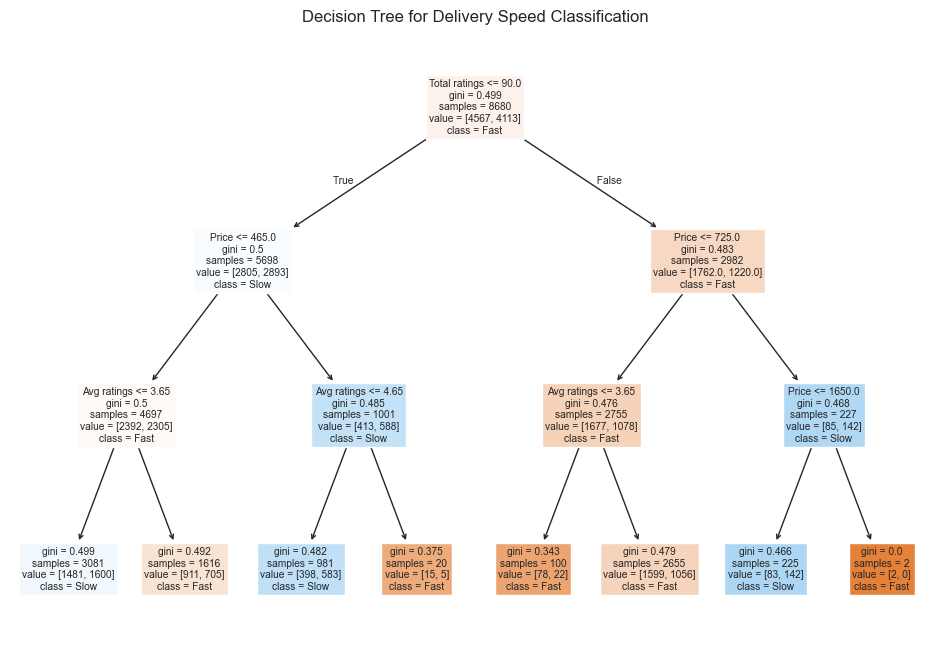

In [87]:
df['delivery_speed'] = df['Delivery time'].apply(
    lambda x: 'Fast' if x <= df['Delivery time'].median() else 'Slow'
)


X = df[['Price', 'Avg ratings', 'Total ratings']]
y = df['delivery_speed']


from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X, y)



from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=['Fast', 'Slow'],
    filled=True
)
plt.title("Decision Tree for Delivery Speed Classification")
plt.show()

## CONCLUSION] 
- Expensive Restaurants tend to deliver food faster.
- Restaurants having a more preference (based on average user ratings) tend to deliver food faster.
- Restaurants having low ratings (based on average user ratings) tend to deliver food slower.

### PROJECT BY:
- **Name:** Om Satyawan Pathak
- **Email:** omsatyawanpathakgit@gmail.com
- **Linkedin:** www.linkedin.com/in/om-satyawan-pathak-029b02368